In [ ]:
import pyorbital
from pyorbital.orbital import Orbital
import datetime as dt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import math
import pandas as pd
import bisect
import uuid
from enum import Enum

from fame import *

In [ ]:
# Behind the scenes, this pulls from Celestrak if we do not specify tle_file

satellites = [
    Satellite("LOFT YAM-3", Orbital("YAM-3", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-5", Orbital("YAM-5", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-7", Orbital("YAM-7", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-8", Orbital("YAM-8", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-10", Orbital("YAM-10", tle_file="TLEs.txt")),
    Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file="TLEs.txt")),
    # "LOFT YAM-3": Orbital("YAM-3"),
]

In [11]:

ground_stations = [
    Location(
        -79.55,
        8.9833,
        0.028,
        "KSAT Panama",
    ),
    Location(
        -51.73363,
        64.182789,
        0,
        "KSAT Nuuk",
    ),
    Location(
        2.53219,
        -72.01243,
        0,
        "KSAT Troll",
    ),
    Location(
        142.3689,
        43.8,
        0,
        "KSAT Hokkaido",
    ),
    Location(
        103.9915,
        1.3661,
        0,
        "KSAT Singapore",
    ),
    Location(
        -70.85021,
        -52.93279,
        0,
        "KSAT Punta Arenas",
    ),
    Location(
        127.7766,
        26.4055,
        0,
        "KSAT Okinawa",
    ),
    Location(
        57.5565,
        -20.1142,
        0,
        "KSAT Mauritius",
    ),
    Location(
        22.62216,
        37.84604,
        0,
        "KSAT Nemea",
    ),
    Location(
        31.12509,
        70.36779,
        0,
        "KSAT Vardo",
    ),
    Location(
        15.39964,
        78.22875,
        0,
        "KSAT Svalbard",
    ),
]

# ground_station_opportunities = [
#     observation_request(
#         lon_deg=gs.lon_deg,
#         lat_deg=gs.lat_deg,
#         alt_km=gs.alt_km,
#         min_time=dt.datetime.now(dt.timezone.utc),
#         max_time=dt.datetime.now(dt.timezone.utc)+ dt.timedelta(seconds=3600*24*2)
#     )
#     for gs in ground_stations
# ]

In [13]:
stride_s = 60
plot_range_s = 10800

In [15]:
ground_stations

[Location KSAT Panama | Lon -79.55°, lat 8.9833°, alt 0.028 km,
 Location KSAT Nuuk | Lon -51.73363°, lat 64.182789°, alt 0 km,
 Location KSAT Troll | Lon 2.53219°, lat -72.01243°, alt 0 km,
 Location KSAT Hokkaido | Lon 142.3689°, lat 43.8°, alt 0 km,
 Location KSAT Singapore | Lon 103.9915°, lat 1.3661°, alt 0 km,
 Location KSAT Punta Arenas | Lon -70.85021°, lat -52.93279°, alt 0 km,
 Location KSAT Okinawa | Lon 127.7766°, lat 26.4055°, alt 0 km,
 Location KSAT Mauritius | Lon 57.5565°, lat -20.1142°, alt 0 km,
 Location KSAT Nemea | Lon 22.62216°, lat 37.84604°, alt 0 km,
 Location KSAT Vardo | Lon 31.12509°, lat 70.36779°, alt 0 km,
 Location KSAT Svalbard | Lon 15.39964°, lat 78.22875°, alt 0 km]

In [16]:
# yam3.get_position(now)
# yam3.get_lonlatalt(now)
# yam3.get_next_passes(now,12,-118,33,0,60,0)

In [17]:
# The first thing you do with a new batch of satellites: plot ground tracks. The simple way.



time_steps_for_plotting = [dt.datetime.now(dt.timezone.utc).replace(tzinfo=None) + dt.timedelta(seconds=stride_s*i) for i in range(int(plot_range_s/stride_s))]

llas = {}
for satellite in satellites:
    llas[satellite] = [satellite.orbit.get_lonlatalt(t) for t in time_steps_for_plotting]


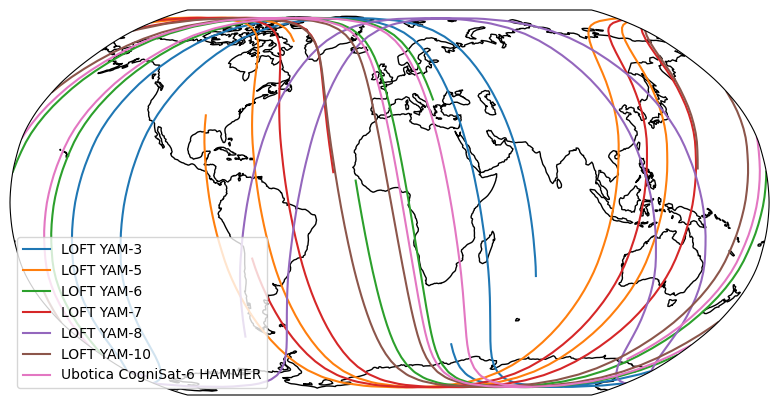

In [19]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()

    # ax.stock_img()
ax.coastlines()
for satellite in llas:
    ax.plot([lla[0] for lla in llas[satellite]],[lla[1] for lla in llas[satellite]],transform=ccrs.Geodetic(), label=satellite.name)
ax.legend()

In [20]:
jpl_lla = [-118.1730155, 34.2009478, 0.329]
passes_horizon_h = 12
passes_error_s = 60
passes_horizon_deg = 0.

passes = {}

for satellite in satellites:
    passes[satellite] = satellite.orbit.get_next_passes(dt.datetime.now(dt.timezone.utc).replace(tzinfo=None),passes_horizon_h,jpl_lla[0],jpl_lla[1],jpl_lla[2],passes_error_s,passes_horizon_deg)

In [21]:
for satellite, passlist in passes.items():
    if len(passlist):
        print("{} passes for {}".format(len(passlist), satellite.name))
        for satpass in passlist:
            print("Start: {}. End: {}. Max altitude: {}".format(satpass[0], satpass[1], satpass[2]))
    else:
        print("No passes for {}".format(satellite.name))

3 passes for LOFT YAM-3
Start: 2025-11-25 01:06:09.232927. End: 2025-11-25 01:16:50.400483. Max altitude: 2025-11-25 01:11:38.919702
Start: 2025-11-25 02:40:42.504410. End: 2025-11-25 02:45:49.240910. Max altitude: 2025-11-25 02:43:15.796317
Start: 2025-11-25 11:32:40.592216. End: 2025-11-25 11:41:47.985621. Max altitude: 2025-11-25 11:37:13.035204
3 passes for LOFT YAM-5
Start: 2025-11-25 03:24:08.016226. End: 2025-11-25 03:27:54.881333. Max altitude: 2025-11-25 03:26:01.289688
Start: 2025-11-25 04:52:45.076067. End: 2025-11-25 05:03:42.868790. Max altitude: 2025-11-25 04:58:09.366958
Start: 2025-11-25 06:28:18.791776. End: 2025-11-25 06:34:50.199494. Max altitude: 2025-11-25 06:31:34.383247
3 passes for LOFT YAM-6
Start: 2025-11-25 08:13:16.373887. End: 2025-11-25 08:17:09.291173. Max altitude: 2025-11-25 08:15:12.672992
Start: 2025-11-25 09:41:54.149929. End: 2025-11-25 09:52:58.182377. Max altitude: 2025-11-25 09:47:29.431536
Start: 2025-11-25 11:17:22.637742. End: 2025-11-25 11:24

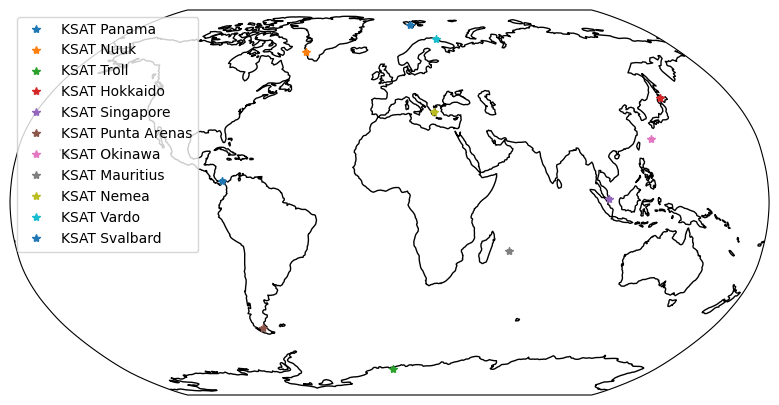

In [22]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()

    # ax.stock_img()
ax.coastlines()
for station in ground_stations:
    ax.plot(station.lon_deg, station.lat_deg,'*',transform=ccrs.Geodetic(), label=station.name)
ax.legend()

In [23]:
print(get_elevation_usgs(-118,34))
print(get_elevation_from_open_elevation(-118,34))

295.55368042
307.0


In [24]:
min_time = dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)
max_time = min_time + dt.timedelta(hours=24)

os = ObservationRequest(-118,34, alt_km=0.307, min_time=min_time, max_time=max_time)

In [25]:
obs_requests = [
    ObservationRequest(-118., 34., min_time=min_time, max_time=max_time, alt_km=0.307),
    ObservationRequest(8., 45., min_time=min_time, max_time=max_time, alt_km=0.216),
    ObservationRequest(-80., 34., min_time=min_time, max_time=max_time, alt_km=0.041),
]

In [26]:
observation_opportunities = find_observation_opportunities(obs_requests, satellites)

In [27]:
# for request, passes in observation_opportunities.items():
#     for satellite, satpasses in passes.items():
#         for satpass in satpasses:
#             print("{}: quality {}".format(satpass.highest, observation_quality(satpass.highest)))

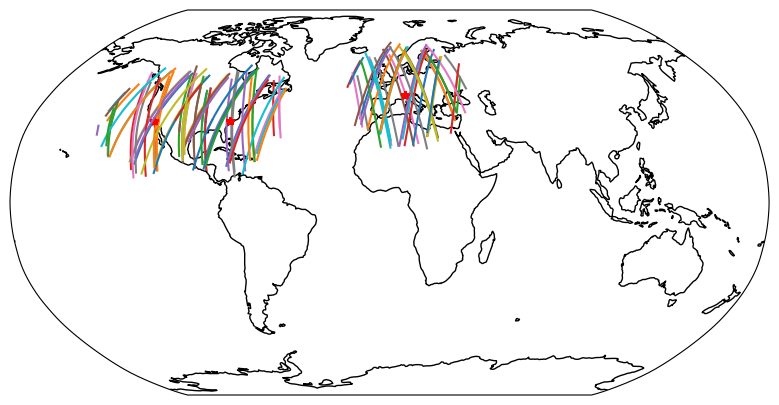

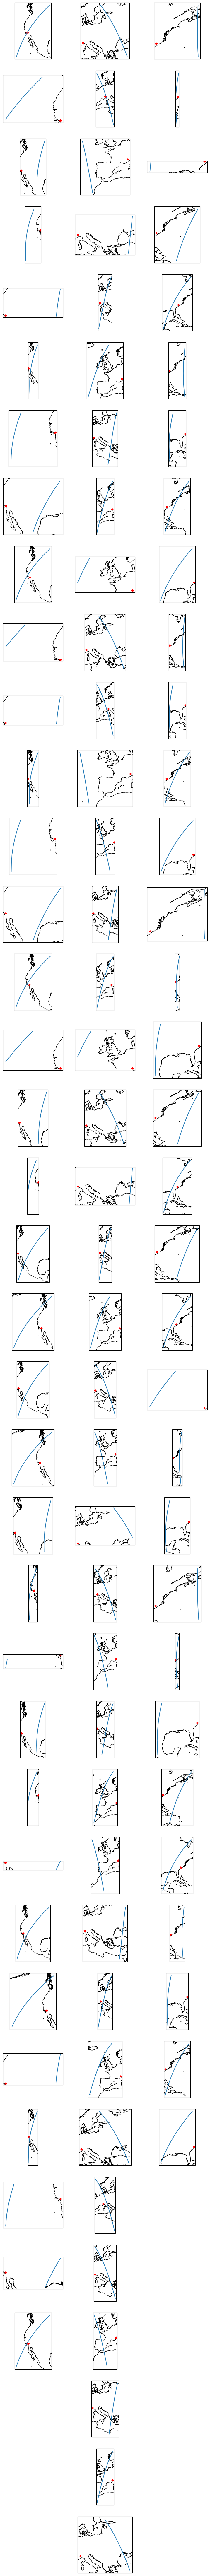

In [28]:
_plot_offset_deg = 20

request_counter = 1
pass_counter = 0

request_number = len(observation_opportunities)
max_num_passes = max([sum([len(passes) for passes in all_passes.values()]) for all_passes in observation_opportunities.values()])

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
axglobal.set_global()
axglobal.coastlines()

fig = plt.figure(figsize=(3*request_number, 3*max_num_passes))

for orequest, all_passes in observation_opportunities.items():
    pass_counter = 0
    for satellite, passes in all_passes.items():
        for satpass in passes:
            ax = fig.add_subplot(max_num_passes, request_number, request_counter + request_number*pass_counter, projection=ccrs.Robinson())
            pass_counter += 1
            # ax.set_global()
            # ax.set_extent((float(orequest.lon_deg)-_plot_offset_deg, float(orequest.lon_deg)+_plot_offset_deg, float(orequest.lat_deg)-_plot_offset_deg, float(orequest.lat_deg)+_plot_offset_deg))
            ax.coastlines()
        
            # request location
            ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
            axglobal.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )

            # Where is the satellite?

            _dt = dt.timedelta(seconds=stride_s)
            time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]

            # for satellite, orbit in satellites.items():
            _orbit = satellite.orbit
            _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
            ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
            axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())

#             # for satellite in llas:
#             #     ax.plot([lla[0] for lla in llas[satellite]],[lla[1] for lla in llas[satellite]],transform=ccrs.Geodetic(), label=satellite)
#             # ax.legend()
    request_counter += 1

## Pick the best request. Greeedy, no conflicts or anything

In [29]:
best_request = {r: None for r in obs_requests}

for request, passes in observation_opportunities.items():
    _best_quality = - np.inf
    _best_satellite = None
    _best_pass = None
    for satellite, satpasses in passes.items():
        for satpass in satpasses:
            _quality = observation_quality(satpass.highest)
            if _quality >= _best_quality:
                _best_quality = _quality
                _best_satellite = satellite
                _best_pass = satpass
            # print("{}: quality {}".format(satpass.highest, observation_quality(satpass.highest)))
    best_request[request] = (_best_satellite, _best_pass)

In [30]:
best_request

{Request  | Lon -118.0°, lat 34.0°, alt 0.307 km from 2025-11-25 00:25:49.317275 to 2025-11-26 00:25:49.317275 with RGB: (LOFT YAM-7,
  Pass start: 2025-11-25 06:42:45.496980, highest: 2025-11-25 06:48:05.230484, fall: 2025-11-25 06:53:32.499480),
 Request  | Lon 8.0°, lat 45.0°, alt 0.216 km from 2025-11-25 00:25:49.317275 to 2025-11-26 00:25:49.317275 with RGB: (Ubotica CogniSat-6 HAMMER,
  Pass start: 2025-11-25 00:56:01.688975, highest: 2025-11-25 01:00:45.779741, fall: 2025-11-25 01:05:30.016347),
 Request  | Lon -80.0°, lat 34.0°, alt 0.041 km from 2025-11-25 00:25:49.317275 to 2025-11-26 00:25:49.317275 with RGB: (LOFT YAM-8,
  Pass start: 2025-11-25 04:29:50.011065, highest: 2025-11-25 04:35:46.815791, fall: 2025-11-25 04:41:38.287033)}

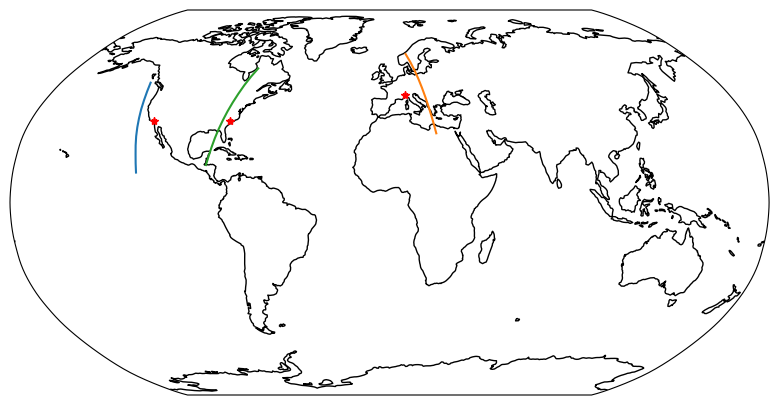

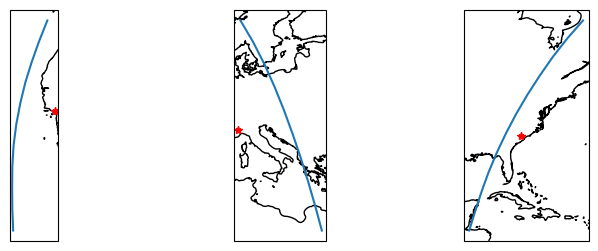

In [31]:
_plot_offset_deg = 20

request_counter = 1

request_number = len(observation_opportunities)

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
axglobal.set_global()
axglobal.coastlines()

fig = plt.figure(figsize=(3*request_number, 3))

for orequest, (satellite, satpass) in best_request.items():
    ax = fig.add_subplot(1, request_number, request_counter, projection=ccrs.Robinson())
    ax.coastlines()

    # request location
    ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
    axglobal.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )

    # Where is the satellite?

    _dt = dt.timedelta(seconds=stride_s)
    time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]

    # for satellite, orbit in satellites.items():
    _orbit = satellite.orbit
    _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
    ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
    axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())

#             # for satellite in llas:
#             #     ax.plot([lla[0] for lla in llas[satellite]],[lla[1] for lla in llas[satellite]],transform=ccrs.Geodetic(), label=satellite)
#             # ax.legend()
    request_counter += 1

For a given set of requests:
- [X] List all the requests. This is what the "most-likely-won't-get-the-observation" policy should request;
- [X] Compute sun angle, view angle, range (for a quality metric)
- [X] Pick the best observation for every opportunity
- [ ] Identify conflicts between observations (slewing time)
- [ ] Pick the best observation for every opportunity with a ILP accounting for conflicts. This is the "I-will-get-every-request" solution.
- [ ] Formulate a MDP with states, actions, transitions, etc.

# More locations

Read a DB of world cities. Generate a good number of locations.

In [32]:
cities_of_the_world = pd.read_csv("simplemaps_worldcities_basicv1.901/worldcities.csv")

In [33]:
sampled_world_cities = cities_of_the_world.sample(n=100,weights='population',axis=0, random_state=0)

In [34]:
one_hundred_sampled_cities = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_world_cities.iterrows()
]

In [36]:
observation_opportunities_cities = find_observation_opportunities(one_hundred_sampled_cities, satellites)

In [37]:
best_request_cities = {r: None for r in one_hundred_sampled_cities}

for request, passes in observation_opportunities_cities.items():
    _best_quality = - np.inf
    _best_satellite = None
    _best_pass = None
    for satellite, satpasses in passes.items():
        for satpass in satpasses:
            _quality = observation_quality(satpass.highest)
            if _quality >= _best_quality:
                _best_quality = _quality
                _best_satellite = satellite
                _best_pass = satpass
            # print("{}: quality {}".format(satpass.highest, observation_quality(satpass.highest)))
    best_request_cities[request] = (_best_satellite, _best_pass)

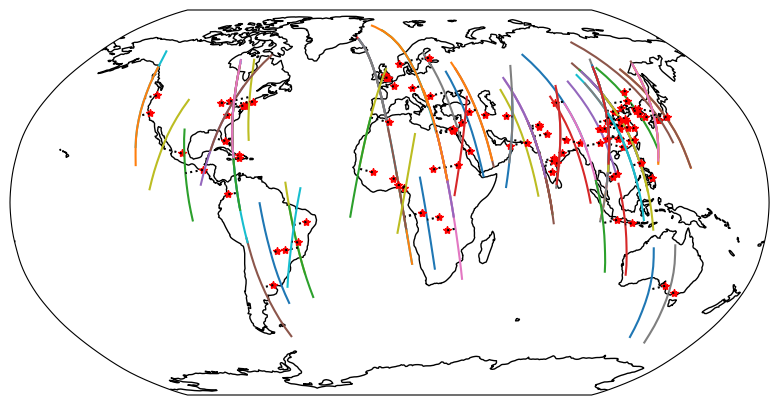

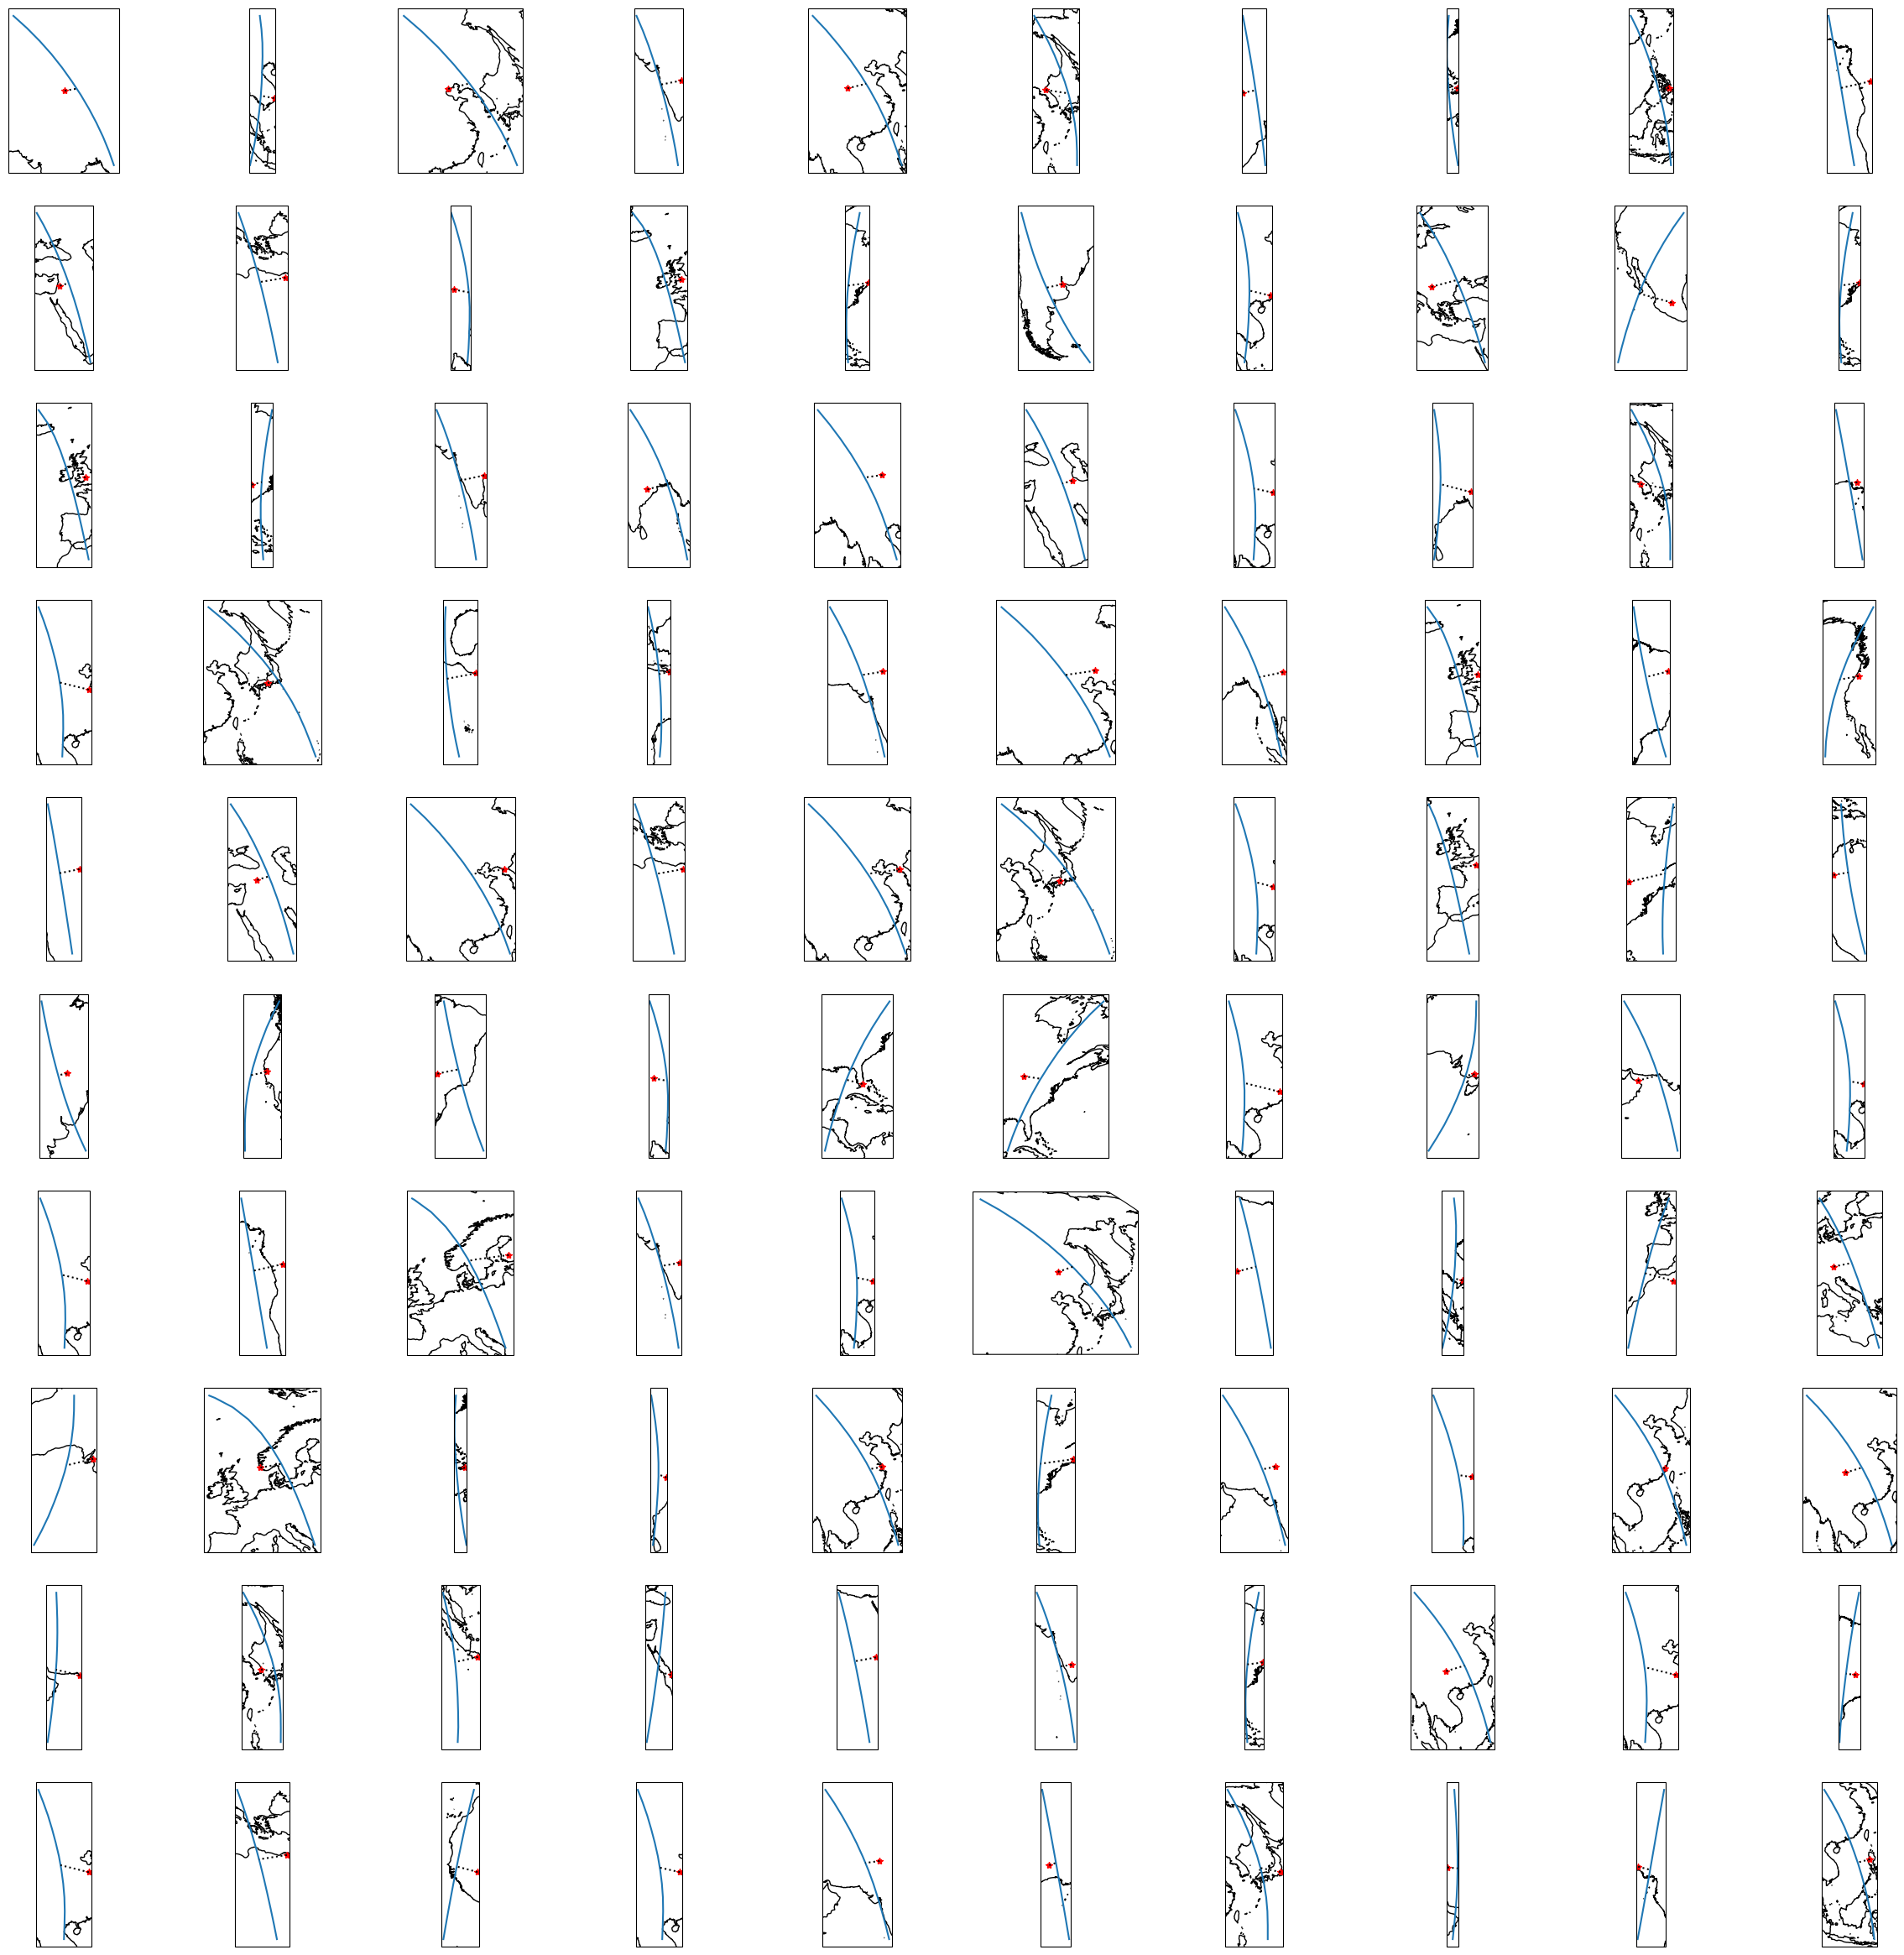

In [38]:
_plot_offset_deg = 20

request_counter = 1

request_number = len(observation_opportunities_cities)

figglobal = plt.figure(figsize=(10,5))
axglobal = figglobal.add_subplot(1,1,1, projection=ccrs.Robinson())
axglobal.set_global()
axglobal.coastlines()

fig = plt.figure(figsize=(int(np.ceil(3*request_number/10)), 3*10))

for orequest, (satellite, satpass) in best_request_cities.items():
    ax = fig.add_subplot(10, int(np.ceil(request_number/10)), request_counter, projection=ccrs.Robinson())
    ax.coastlines()

    # request location
    ax.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )
    axglobal.plot(float(orequest.lon_deg), float(orequest.lat_deg), '*r', transform=ccrs.PlateCarree(), )

    # Where is the satellite?

    _dt = dt.timedelta(seconds=stride_s)
    time_steps_for_plotting = [satpass.rise.time + _dt*i for i in range(int(math.ceil((satpass.fall.time-satpass.rise.time).total_seconds()/_dt.total_seconds())))]

    _orbit = satellite.orbit
    _llas = [_orbit.get_lonlatalt(t) for t in time_steps_for_plotting]
    ax.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())
    axglobal.plot([lla[0] for lla in _llas],[lla[1] for lla in _llas],transform=ccrs.Geodetic())

    # Where is the satellite looking?
    _highest_lla = _orbit.get_lonlatalt(satpass.highest.time)
    axglobal.plot(
        [float(orequest.lon_deg), _highest_lla[0]],
        [float(orequest.lat_deg), _highest_lla[1]],
        ':k',
        transform=ccrs.Geodetic()
    )
    ax.plot(
        [float(orequest.lon_deg), _highest_lla[0]],
        [float(orequest.lat_deg), _highest_lla[1]],
        ':k',
        transform=ccrs.Geodetic()
    )
    
    request_counter += 1

# Simulation

Let's talk about simulation.

We want an event-based sim. There is a global ordered timeline and the sim jumps from event to event.

Continuous transitions (power, thermal, etc) are discretized in this setting.

We need a few entities here.

Agent: a satellite, a constellation manager, a requestor. 

Event: something on the ground turning on or off.

Communication: something that affects the state of two entities.

Observation: a query of an agent to (event, empty set). If we want to be fancy, a query of an agent to a region, where events are or are 
not associated with regions.

Prototype:
- A Satellite class with a list of Observations
- A ConstellationManager class with a list of Satellites which can query Observations and add new ones.
  - A ConstellationManager class that updates the Satellites' Observations when a Communication event occurs.
- An Observation of a Region.
    - Observe. Returns an image of the region.
    - Search. Returns True if there is an Event in the Region. The event is stored.
    - Monitor. Returns True if the event is still active.
    - Something for moving events?
- Phenomenon: something with a spatial position, start time, end time, potentially internal states.

The simulator holds:
- Agents (Satellites, ConstellationManagers)
- Phenomena.
- A list of Events (Observation, Communication, Phenomenon transitions), encoded as functions.
The output of the functions affects the agents and phenomena.

We need to define:

- An Observation Opportunity (observation_opportunity)
- An Observer, which has an Orbit, a list of Observation Opportunities to execute, a list of ObservedEvents it has observed (with their state), and a list of DataProducts.
- A ConstellationManager, which has a list of ObserverStates (Orbit, ObservationOpportunities) and a list of CommunicationOpportunities with Observers. When there is a CommunicationOpportunity the ConstellationManager can push an updated list of ObservationOpportunities.
- An Event, with a lonlatalt, a State (enum), and times for StateTransitions.
- 

In [39]:
MIN_HORIZON_ANGLE_FOR_PASS_DEG = 15
MIN_HORIZON_ANGLE_FOR_OBS_DEG = 15

class Event():
    def __init__(self, time: dt.datetime, action_callable, name: str="", id: str=None):
        self.time = time
        self.action_callable = action_callable
        self.name = name
        if id is None:
            id = uuid.uuid4()
        self.id = id
    def __str__(self):
        return "Event {} at {}".format(self.name, self.time)
    def __repr__(self):
        return self.__str__()

# class Satellite():
# defined above

class Phenomenon(Location):
    def __init__(self, lon_deg: float, lat_deg: float, alt_km: float, start_time: dt.datetime, end_time: dt.datetime, name: str=""):
        super().__init__(lon_deg=lon_deg, lat_deg=lat_deg, alt_km=alt_km, name=name)
        # self.lon_deg = lon_deg
        # self.lat_deg = lat_deg
        # self.alt_km = alt_km
        self.start_time = start_time
        self.end_time = end_time
        # self.name = name
    def __str__(self):
        return "{}: Lon {}, lat {}, alt {}, start {}, end {}".format(self.name, self.lon_deg,self.lat_deg,self.alt_km, self.start_time, self.end_time)
    def __repr__(self):
        return self.__str__()

   
class World():
    def __init__(self, agents: list=[], phenomena: list = [], events: list = []):
        self.agents = agents
        self.phenomena = phenomena
        self.events = events
        self.time = dt.datetime.min
    
    def tick(self, print_forbidden_prefixes=[]):
        if len(self.events):
            _event = self.events.pop(0)
            _print_event_name = True
            for forbidden_names in print_forbidden_prefixes:
                if _event.name.startswith(forbidden_names):
                    _print_event_name = False
                    break
            if _print_event_name:
                print("Executing {}".format(_event))
            outcome = _event.action_callable()
            self.time = _event.time
            
        else:
            print("No more events")
            pass
        return len(self.events)

    def add_agent(self, agent):
        self.agents.append(agent)
    
    def add_event(self, event):
        # print("Adding {}".format(event))
        if (event.time<self.time):
            raise ValueError("Event {} is earlier than sim time {}".format(event, self.time)) 
        bisect.insort(self.events, event, key=lambda x: x.time)
        
    def do_observation(self, observation: ObservationOpportunity, spacecraft: Satellite):
        # Find phenomena close to the observation location in space and at the right time
        # Return a data product and a list of event states
        # print("Obs opp {}".format(observation))
        observed_phenomena = []

        # Now let's see what we observed
        for _phenomenon in self.phenomena:
            if (_phenomenon.start_time <= observation.time and _phenomenon.end_time > observation.time):
                # print("Candidate phenomenon {}".format(_phenomenon))
                
                # Compute phenomenon location on the planet
                _ph_location_ecf = np.array(pyorbital.astronomy.observer_position(observation.time, _phenomenon.lon_deg, _phenomenon.lat_deg, _phenomenon.alt_km)[0][:3])
                        # print(np.array(orbit.get_position(_time, normalize=False)))
                # print("Ph location {}".format(_ph_location_ecf))
                # Compute observation location on the planet
                _obs_location_ecf = np.array(pyorbital.astronomy.observer_position(observation.time, observation.lon_deg, observation.lat_deg, observation.alt_km)[0][:3])
                # print("Obs location {}".format(_obs_location_ecf))
                # Compute SC location
                _sc_location_ecf = np.array(spacecraft.orbit.get_position(observation.time, normalize=False)[0][:3])
                # print("Sc location {}".format(_sc_location_ecf))
                # Compute angle between sc-observation and sc-phenomenon
                _ph_sc_vector = _ph_location_ecf-_sc_location_ecf
                _obs_sc_vector = _obs_location_ecf - _sc_location_ecf
                # print("PhSc {} || ObsSc {}".format(_ph_sc_vector, _obs_sc_vector))
                # print("Dot: {} || N1: {} N2: {}".format(np.dot(_ph_sc_vector,_obs_sc_vector),np.linalg.norm(_ph_sc_vector,2), np.linalg.norm(_obs_sc_vector,2))) 
                # print("Acos: {}, angle: {}".format(np.dot(_ph_sc_vector,_obs_sc_vector)/(np.linalg.norm(_ph_sc_vector,2)*np.linalg.norm(_obs_sc_vector,2)), np.arccos(np.dot(_ph_sc_vector,_obs_sc_vector)/(np.linalg.norm(_ph_sc_vector,2)*np.linalg.norm(_obs_sc_vector,2)))))
                _ph_obs_angle_rad = np.arccos(np.clip(np.dot(_ph_sc_vector,_obs_sc_vector)/(np.linalg.norm(_ph_sc_vector,2)*np.linalg.norm(_obs_sc_vector,2)),-1,1))
                # print("Obs angle (rad) {}".format(_ph_obs_angle_rad))
                # If angle<FOV, return phobservation
                if _ph_obs_angle_rad < spacecraft.instrument_fov_rad[observation.instrument]:
                    # print("Close enough")
                    observed_phenomena.append(_phenomenon)
                else:
                    # print("Too far")
                    pass
        # Store SOMETHING for the completed observation
        spacecraft.data_products.append(observation)
        spacecraft.known_phenomena.append(observed_phenomena)
        
        return True
        







In [40]:
def do_downlink(spacecraft: Satellite, scheduler, comm_pass: ObservationPass): # scheduler is a ConstellationGroundScheduler,defined next 
    # Simple: downlink all. Future: downlink up to x.
    
    # Duration is unused for now
    duration = comm_pass.fall.time - comm_pass.rise.time

    _downlinked = []
    if len(spacecraft.data_products):
        print("Spacecraft {} has {} data products to download".format(spacecraft, len(spacecraft.data_products)))
        
    for data_product in spacecraft.data_products:
        print("  Downlinked {}".format(data_product))
        _downlinked.append(data_product)

        # found_the_requestor = False
        # for _req, _reqdata in scheduler.requests.items():
        #     if data_product == _reqdata['observation']:
        #         _reqdata['status'] = "OK! Data received"
        #         _reqdata['data_product'] = data_product
        #         # This lets the caller know
        #         _reqdata['ready_callback'](data_product)
        #         found_the_requestor = True
        #         break
        
        matching_requests = scheduler._requests[scheduler._requests['observation']==data_product]
        # print(scheduler._requests)
        # print(matching_requests)
        if len(matching_requests):
            # my_request = matching_requests[0]
            scheduler._requests.loc[scheduler._requests['observation']==data_product, 'status'] = "OK! Data received"
            scheduler._requests.loc[scheduler._requests['observation']==data_product, 'data_product'] = data_product
            scheduler._requests.loc[scheduler._requests['observation']==data_product, 'ready_callback'].item()(data_product)
            # my_request.status = "OK! Data received"
            # my_request.data_product = data_product
        #   my_request.ready_callback(data_product)

        # if (found_the_requestor):
        #     print(".  This DP {} is for {}".format(data_product, _req))
        # else:
        #     print("   I downlinked something but I don't know who it's for!\n   DP: {}, requests: {}".format(data_product, scheduler.requests))

        

    for _dp in _downlinked:
        spacecraft.data_products.remove(_dp)

In [41]:
class ConstellationGroundScheduler():
    def __init__(self, satellites: list, ground_stations: list, world: World, name="Constellation"):
        self.name = name
        self.satellites = satellites
        self.ground_stations = ground_stations
        self.world = world
        # self.requests = {}
        self._requests = pd.DataFrame(columns=['request', 'satellite', 'observation', 'uplink', 'downlink', 'status', 'data_product', 'scheduled_callback', 'unscheduled_callback', 'ready_callback'])

    def screen_request_for_feasibility(self, _request: ObservationRequest, screen_against_comm_passes:bool=True):
        conflicting_requests = self._requests.loc[
            self._requests.apply(
            lambda x: 
                (x['status']=="Scheduled") and # We have actually scheduled this
                (x['observation'].time+x['observation'].duration > _request.time) and # The end of the other observation is after we start
                (x['observation'].time < _request.time+_request.duration)  # The start of the other observation is before we end
            , axis=1)]
        if len(conflicting_requests):
            return False
        if (screen_against_comm_passes):
            conflicting_uplinks = self._requests.loc[
                self._requests.apply(
                lambda x: 
                    (x['status']=="Scheduled") and # We have actually scheduled this
                    (x['uplink'].fall.time > _request.time) and # The end of the comm pass is after we start
                    (x['uplink'].rise.time < _request.time + _request.duration) # The start of the comm pass is before we end
                , axis=1)]
            if len(conflicting_uplinks):
                return False
            conflicting_downlinks = self._requests.loc[
                self._requests.apply(
                lambda x: 
                    (x['status']=="Scheduled") and # We have actually scheduled this
                    (x['downlink'].fall.time > _request.time) and # The end of the comm pass is after we start
                    (x['downlink'].rise.time < _request.time + _request.duration) # The start of the comm pass is before we end
                , axis=1)]
            if len(conflicting_downlinks):
                return False
        return True
    
    def screen_pass_for_feasibility(self, _obs_pass: ObservationPass, screen_against_comm_passes:bool=False):
        conflicting_requests = self._requests.loc[
            self._requests.apply(
            lambda x: 
                (x['status']=="Scheduled") and # We have actually scheduled this
                (x['observation'].time+x['observation'].duration > _obs_pass.rise.time) and # The end of the other observation is after we start
                (x['observation'].time < _obs_pass.fall.time)  # The start of the other observation is before we end
            , axis=1)]
        if len(conflicting_requests):
            return False
        if (screen_against_comm_passes):
            conflicting_uplinks = self._requests.loc[
                self._requests.apply(
                lambda x: 
                    (x['status']=="Scheduled") and # We have actually scheduled this
                    (x['uplink'].fall.time > _obs_pass.rise.time) and # The end of the comm pass is after we start
                    (x['uplink'].rise.time < _obs_pass.fall.time) # The start of the comm pass is before we end
                , axis=1)]
            if len(conflicting_uplinks):
                return False
            conflicting_downlinks = self._requests.loc[
                self._requests.apply(
                lambda x: 
                    (x['status']=="Scheduled") and # We have actually scheduled this
                    (x['downlink'].fall.time > _obs_pass.rise.time) and # The end of the comm pass is after we start
                    (x['downlink'].rise.time < _obs_pass.fall.time) # The start of the comm pass is before we end
                , axis=1)]
            if len(conflicting_downlinks):
                return False
        return True

    def schedule_request(
            self,
            request: ObservationRequest,
            current_time: dt.datetime=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None),
            callback_request_scheduled=lambda req_pass: None,
            callback_request_unscheduled=lambda reason: None,
            callback_request_ready=lambda data_product: None,
            ):
        # Pick the best satellite to fulfill this. This is where we'll need to be smarter. Or not! Just pick something starting the day after.
        print("[{}] Scheduling request {}".format(self.name, request))
        # self.requests[request] = {
        _request_dict = {
            'request': request,
            'satellite': None,
            'observation': None,
            'uplink': None,
            'downlink': None,
            'status': None,
            'data_product': None,
            'scheduled_callback': callback_request_scheduled,
            'unscheduled_callback': callback_request_unscheduled,
            'ready_callback': callback_request_ready,
        }

        # _pdrequest = pd.DataFrame([self.requests[request]])
        _pdrequest = pd.DataFrame([_request_dict])

        self._requests = pd.concat([self._requests, _pdrequest], ignore_index=True)
              
        _opportunities = find_observation_opportunities(
            [request,],
            satellites=self.satellites,
            passes_error_s=60,
            passes_horizon_deg=MIN_HORIZON_ANGLE_FOR_OBS_DEG
        )
        if len(_opportunities):
            # best_request = None
            passes = _opportunities[request]
            # for request, passes in _opportunities.items(): # Only one request, so this just unpacks the opportunities and its OK to reset best_quality below
            if len(passes):
                _best_quality = - np.inf
                _best_satellite = None
                _best_pass = None
                for satellite, satpasses in passes.items():
                    for satpass in satpasses:
                        # TODO check if the satellite is free at this time.
                        # Query the table of observations for 1. planned, 2. on the satellite we are examining.
                        # Check by time if there is something nearby.
                        # If there is, back off.
                        _pass_is_feasible = self.screen_request_for_feasibility(satpass.highest)
                        if (_pass_is_feasible == False):
                            continue
                        # conflicting_requests = self._requests.loc[
                        #     self._requests.apply(
                        #     lambda x: 
                        #         (x['status']=="Scheduled") and # We have actually scheduled this
                        #         (x['observation'].time+x['observation'].duration > satpass.highest.time) and # The end of the other observation is after we start
                        #         (x['observation'].time < satpass.highest.time+satpass.highest.duration)  # The start of the other observation is before we end
                        #     , axis=1)]
                        # if len(conflicting_requests):
                        #     continue
                        # conflicting_uplinks = self._requests.loc[
                        #     self._requests.apply(
                        #     lambda x: 
                        #         (x['status']=="Scheduled") and # We have actually scheduled this
                        #         (x['uplink'].fall.time > satpass.highest.time) and # The end of the comm pass is after we start
                        #         (x['uplink'].rise.time < satpass.highest.time + satpass.highest.duration) # The start of the comm pass is before we end
                        #     , axis=1)]
                        # if len(conflicting_uplinks):
                        #     continue
                        # conflicting_downlinks = self._requests.loc[
                        #     self._requests.apply(
                        #     lambda x: 
                        #         (x['status']=="Scheduled") and # We have actually scheduled this
                        #         (x['downlink'].fall.time > satpass.highest.time) and # The end of the comm pass is after we start
                        #         (x['downlink'].rise.time < satpass.highest.time + satpass.highest.duration) # The start of the comm pass is before we end
                        #     , axis=1)]
                        # if len(conflicting_downlinks):
                        #     continue

                        _quality = observation_quality(satpass.highest)
                        if _quality >= _best_quality:
                            _best_quality = _quality
                            _best_satellite = satellite
                            _best_pass = satpass
                        # print("{}: quality {}".format(satpass.highest, observation_quality(satpass.highest)))
                # best_request = (_best_satellite, _best_pass)
                print("Best request: {} with {}".format(_best_pass, _best_satellite))
                if (_best_pass is None):
                    print("All observation opportunities are conflicting")
                    # self.requests[request]['status'] = "No observation opportunities"
                    self._requests.loc[self._requests['request']==request, 'status'] = "All observation opportunities are conflicting"
                    callback_request_unscheduled("All observation opportunities are conflicting")
                    return -5
            else:
                print("No observation opportunities here")
                print(_opportunities)
                # self.requests[request]['status'] = "No observation opportunities"
                self._requests.loc[self._requests['request']==request, 'status'] = "No observation opportunities"
                callback_request_unscheduled("No observation opportunities")
                return -1
        else:
            print("Something wrong with requests list, did you pass a request?")
        
        # Pick the best contact to tell the satellite. What if the contact is after the request? Whoops.
        _, ul_comm_opportunities = find_contact_opportunities(
            ground_stations=self.ground_stations,
            satellites=self.satellites,
            min_time=current_time,
            max_time=_best_pass.highest.time,
            passes_error_s=60,
            passes_horizon_deg=MIN_HORIZON_ANGLE_FOR_PASS_DEG,
        )

        if ((_best_satellite in ul_comm_opportunities.keys()) and (len(ul_comm_opportunities[_best_satellite])))==0:
            # No contacts!
            print("No timely contact! Maybe we were too greedy")
            # self.requests[request]['status'] = "No timely contact";
            self._requests.loc[self._requests['request']==request, 'status'] = "No timely contact";
            callback_request_unscheduled("No timely contact")
            return -2
        
        earliest_comm_opportunity = None
        earliest_comm_opportunity_station = None
        for comm_opportunity in ul_comm_opportunities[_best_satellite]:
            if self.screen_pass_for_feasibility(comm_opportunity[1], screen_against_comm_passes=False):
                earliest_comm_opportunity = comm_opportunity[1]
                earliest_comm_opportunity_station = comm_opportunity[0]

        if ((earliest_comm_opportunity is None) or (earliest_comm_opportunity_station is None)):
            print("No timely unconflicted contact! Maybe we were too greedy")
            # self.requests[request]['status'] = "No timely contact";
            self._requests.loc[self._requests['request']==request, 'status'] = "No timely unconflicted contact";
            callback_request_unscheduled("No timely unconflicted contact")
            return -2.5

        _best_sat_object = None
        for sat in self.satellites:
            if sat.name == _best_satellite.name:
                _best_sat_object = sat
        if (_best_sat_object is None):
            print("ERROR! Something wrong with finding the satellite")
            # self.requests[request]['status'] = "Could not find best satellite";
            self._requests.loc[self._requests['request']==request, 'status'] = "Could not find best satellite";

            callback_request_unscheduled("Could not find best satellite")
            return -3

        # Let's also schedule a downlink after the event
        # Find downlink opportunities
        _, _dl_comm_opportunities = find_contact_opportunities(
            ground_stations=self.ground_stations,
            satellites=[_best_sat_object, ],
            min_time=_best_pass.highest.time+_best_pass.highest.duration,
            max_time=_best_pass.highest.time+_best_pass.highest.duration+dt.timedelta(hours=48),
            passes_error_s=60,
            passes_horizon_deg=MIN_HORIZON_ANGLE_FOR_PASS_DEG,
        )
        # # Schedule downlink events for those
        if _best_sat_object not in _dl_comm_opportunities.keys() or len(_dl_comm_opportunities[_best_sat_object]) == 0:
            print("  Could not find a suitable downlink")
            # self.requests[request]['status'] = "Could not find best satellite";
            self._requests.loc[self._requests['request']==request, 'status'] = "No timely downlink";
            callback_request_unscheduled("No timely downlink")
            return -4
        
        ## 

        # Passes are sorted by time. An we checked above that there is at least one pass
        _preferred_downlink_pass = _dl_comm_opportunities[_best_sat_object][0]
        _dl_station = _preferred_downlink_pass[0]
        _dl_pass = _preferred_downlink_pass[1]

        _dl_station = None
        _dl_pass = None
        for comm_opportunity in _dl_comm_opportunities[_best_sat_object]:
            if self.screen_pass_for_feasibility(comm_opportunity[1], screen_against_comm_passes=False):
                _dl_pass = comm_opportunity[1]
                _dl_station = comm_opportunity[0]

        if ((_dl_pass is None) or (_dl_station is None)):
            print("  Could not find a suitable unconflicted downlink")
            # self.requests[request]['status'] = "No timely contact";
            self._requests.loc[self._requests['request']==request, 'status'] = "No timely unconflicted downlink";
            callback_request_unscheduled("No timely unconflicted downlink")
            return -4.5

        ##


        schedule_observation_uplink(self.world, _best_sat_object, earliest_comm_opportunity, _best_pass.highest, earliest_comm_opportunity_station)
        schedule_sat_downlink(_world=self.world, satellite=_best_sat_object, comm_pass = _dl_pass, station = _dl_station, constellation_scheduler=self)
        # # Do downlink
        
        # # Schedule an event where we tell the satellite about this. The event calls schedule_observation
        # TODO 
        # - pick the earliest opportunity
        # - check it's early enough (if not return)
        # - schedule an Event at the comm opportunity time that, when triggered, calls schedule_observation with best_request
        self._requests.loc[self._requests['request']==request, 'satellite'] = _best_sat_object
        self._requests.loc[self._requests['request']==request, 'observation'] = _best_pass.highest
        self._requests.loc[self._requests['request']==request, 'uplink'] = earliest_comm_opportunity
        self._requests.loc[self._requests['request']==request, 'downlink'] = _dl_pass
        self._requests.loc[self._requests['request']==request, 'status'] = "Scheduled";

        callback_request_scheduled(_best_pass.highest)
        return 0

    def schedule_downlinks(
        self,
        current_time: dt.datetime=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None),
        max_time: dt.datetime=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)+dt.timedelta(hours=24)
    ):
        # Find downlink opportunities
        _, comm_opportunities = find_contact_opportunities(
            ground_stations=self.ground_stations,
            satellites=self.satellites,
            min_time=current_time,
            max_time=max_time,
            passes_error_s=60,
            passes_horizon_deg=MIN_HORIZON_ANGLE_FOR_PASS_DEG,
        )
        # Schedule downlink events for those
        for _sat, _comm_passes_and_stations in comm_opportunities.items():
            # print(_comm_pass_and_station)
            # print(_sat)
            for _comm_pass_and_station in _comm_passes_and_stations:
                _station = _comm_pass_and_station[0]
                _comm_pass = _comm_pass_and_station[1]
                schedule_sat_downlink(_world=self.world, satellite=_sat, comm_pass = _comm_pass, station = _station, constellation_scheduler=self)
        # Do downlink
    
    def get_request_status(self, request: ObservationRequest):
        return self._requests[self._requests['request'] == request].status
        if request in self.requests:
            return self.requests[request].status
        else:
            return None

In [42]:
def schedule_observation(_world, satellite: Satellite, obs_opportunity):
    # An observation fires at the time of the observation. It adds known events to the satellite's known_phenomena store.
    # TODO it also adds an observation product to the satellite's 

    # This first bit is quite redundant. What you want is to maintain events for individual agents and then a global copy, right?



    satellite.scheduled_observations.append(obs_opportunity)

    def unlock_satellite(_satellite):
        if _satellite.attitude_controller_state == AttitudeController.INSTRUMENT:
            _satellite.attitude_controller_state = AttitudeController.FREE
            _satellite.busy_with = None
            return True
        else:
            return False

    def lock_satellite_and_observe(_satellite, _obs_opportunity, __world):
        if _satellite.attitude_controller_state != AttitudeController.FREE:
            print("Satellite busy ({})! Sat {} attempted observation {}".format(_satellite.attitude_controller_state, _satellite, _obs_opportunity))
            return False
        _satellite.attitude_controller_state = AttitudeController.INSTRUMENT
        _satellite.busy_with = _obs_opportunity

        _unlock_event = Event(
            name = "Unlock satellite after obs, sat {}".format(_satellite.name),
            time = _obs_opportunity.time+_obs_opportunity.duration,
            action_callable = lambda _sate=satellite: unlock_satellite(_sate)
        )
        _world.add_event(_unlock_event)
        return __world.do_observation(_obs_opportunity, _satellite)
    
    _event = Event(
        name = "Obs, sat {}".format(satellite.name),
        time = obs_opportunity.time,
        # Note the kludge of default inputs to make sure the closure works and we capture the variables at the time of creation
        # action_callable = lambda _opp=_opportunity, _satname=_sat.name: print("{} with {}".format(_opp, _satname)) #_sat.known_phenomena.append(world.do_observation(_opportunity, _sat))
        # action_callable = lambda _opp=obs_opportunity, _sate=satellite: _world.do_observation(_opp, _sate)
        action_callable = lambda _opp=obs_opportunity, _sate=satellite, __world=_world: lock_satellite_and_observe(_sate, _opp, __world)
    )
    _world.add_event(_event)

    return 0

def schedule_observation_uplink(_world: World, satellite: Satellite, comm_opportunity: ObservationPass, obs_opportunity: ObservationOpportunity, station: Location):
    # An observation uplink fires at the time of the uplink. It adds an event that will trigger the observation at the appropriate time. 
    if (comm_opportunity.highest.time>obs_opportunity.time):
        raise ValueError("Uplink {} is after related observation {}".format(comm_opportunity, obs_opportunity))
    
    def unlock_satellite(_satellite, verbose=False):
        if (_satellite.attitude_controller_state == AttitudeController.COMMUNICATION 
            and _satellite.busy_with == comm_opportunity):
            _satellite.attitude_controller_state = AttitudeController.FREE
            _satellite.busy_with = None
            return True
        else:
            if verbose:
                print("Could not unlock satellite after ul comm opportunity with station {} at {}!".format(station, comm_opportunity.highest.time))
            return False
        
    def do_uplink_event(__world: World, __satellite: Satellite, __obsopp: ObservationOpportunity):
        if __satellite.attitude_controller_state == AttitudeController.INSTRUMENT:
            print("Satellite busy! Attempted uplink to sat {} from station {}".format(__satellite, station))
            return False
        __satellite.attitude_controller_state == AttitudeController.COMMUNICATION
        __satellite.busy_with = comm_opportunity
        _unlock_event = Event(
            name = "Unlock uplink, station {} to sat {}".format(station.name, __satellite.name),
            time = comm_opportunity.fall.time,
            action_callable = lambda _sate=satellite: unlock_satellite(_sate)
        )
        __world.add_event(_unlock_event)
        return schedule_observation(__world, __satellite, __obsopp)

    _event = Event(
        name="Uplink, station {} to sat {}".format(station.name, satellite.name),
        time = comm_opportunity.highest.time,
        # action_callable = lambda _w=_world, _s=satellite, _o=obs_opportunity: schedule_observation(_w, _s, _o)
        action_callable = lambda _w=_world, _s=satellite, _o=obs_opportunity: do_uplink_event(_w, _s, _o)
    )
    _world.add_event(_event)

def schedule_sat_downlink(
    _world: World,
    satellite: Satellite,
    comm_pass: ObservationPass,
    station: Location,
    constellation_scheduler: ConstellationGroundScheduler
):
    
    def unlock_satellite(_satellite, verbose=False):
        if (_satellite.attitude_controller_state == AttitudeController.COMMUNICATION 
            and _satellite.busy_with == comm_pass):
            _satellite.attitude_controller_state = AttitudeController.FREE
            _satellite.busy_with = None
            return True
        else:
            if verbose:
                print("Could not unlock satellite after dl comm opportunity with station {} at {}!".format(station, comm_pass.highest.time))
            return False
        
    def end_downlink_event(_spacecraft: Satellite, _scheduler: ConstellationGroundScheduler, _comm_pass: ObservationPass):
        do_downlink(spacecraft=_spacecraft, scheduler=_scheduler, comm_pass=_comm_pass)
        return unlock_satellite(_spacecraft)

    def start_downlink_event(_spacecraft: Satellite, _scheduler: ConstellationGroundScheduler, _comm_pass: ObservationPass):
        if _spacecraft.attitude_controller_state == AttitudeController.INSTRUMENT:
            print("Satellite busy! Attempted downlink to sat {} from station {} at ".format(_spacecraft, station, _comm_pass.rise.time))
            return False
        _spacecraft.attitude_controller_state = AttitudeController.COMMUNICATION
        _spacecraft.busy_with = _comm_pass

        _end_event = Event(
            name="End of downlink, station {} from sat {}".format(station.name, satellite.name),
            time = _comm_pass.fall.time,
            # action_callable = lambda _cs=_scheduler, _s=_spacecraft, _c=_comm_pass: do_downlink(spacecraft=_s, scheduler=_cs, comm_pass=_c)
            action_callable = lambda _cs=_scheduler, _s=_spacecraft, _c=_comm_pass: end_downlink_event(_spacecraft=_s, _scheduler=_cs, _comm_pass=_c)
        )
        _world.add_event(_end_event)
        return True


    _event = Event(
        name="Downlink, station {} from sat {}".format(station.name, satellite.name),
        time = comm_pass.rise.time,
        # action_callable = lambda _cs=constellation_scheduler, _s=satellite, _c=comm_pass: do_downlink(spacecraft=_s, scheduler=_cs, comm_pass=_c)
        action_callable = lambda _cs=constellation_scheduler, _s=satellite, _c=comm_pass: start_downlink_event(_spacecraft=_s, _scheduler=_cs, _comm_pass=_c)
    )
    _world.add_event(_event)

Something simple. 
- [X] Create a world.
- [X] Add satellites to it.
- [X] Add observation opportunities to the satellites manually
- [X] Click until out of events
- [X] Add a better way to add observation opportunities!
- [X] Add a ConstellationScheduler 

In [43]:
phenomena = [
    Phenomenon(
        lon_deg = -118.,
        lat_deg = 34.,
        alt_km=0.307,
        start_time=min_time,
        end_time=max_time,

    ),
    Phenomenon(8., 45.,  alt_km=0.216, start_time=min_time, end_time=max_time),
    Phenomenon(-80., 34., alt_km=0.041, start_time=min_time, end_time=max_time),
]

In [44]:
phenomena_cities = [
    Phenomenon(
        lon_deg = city.lon_deg,
        lat_deg = city.lat_deg,
        alt_km=city.alt_km,
        start_time=city.min_time,
        end_time=city.max_time,
        name=city.name
    ) for city in one_hundred_sampled_cities
]

In [45]:
one_hundred_sampled_cities[0].min_time

datetime.datetime(2025, 11, 25, 0, 25, 49, 317275)

In [46]:
satellite_agents_simple = [
    Satellite("LOFT YAM-3", Orbital("YAM-3", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-5", Orbital("YAM-5", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-7", Orbital("YAM-7", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-8", Orbital("YAM-8", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-10", Orbital("YAM-10", tle_file="TLEs.txt")),
    Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file="TLEs.txt")),
    # "LOFT YAM-3": Orbital("YAM-3"),
]

In [47]:
world = World(agents = satellite_agents_simple, phenomena=phenomena)

Manually add observation opportunities

In [48]:
for req, opp in best_request.items():
    for _sat in world.agents:
        if _sat.name == opp[0].name:
            _opportunity = opp[1].highest
            print("{} {} {}".format(_sat.name, req, _opportunity))

            schedule_observation(world, _sat, _opportunity)

LOFT YAM-7 Request  | Lon -118.0°, lat 34.0°, alt 0.307 km from 2025-11-25 00:25:49.317275 to 2025-11-26 00:25:49.317275 with RGB Observation  at 2025-11-25 06:48:05.230484 with RGB. Look angle 261.40162126740523 | 29.88729624302942 az/dec deg, zenith angle 162.65859288832667 deg, range 885.4456819389353 km, duration 0:01:00
Ubotica CogniSat-6 HAMMER Request  | Lon 8.0°, lat 45.0°, alt 0.216 km from 2025-11-25 00:25:49.317275 to 2025-11-26 00:25:49.317275 with RGB Observation  at 2025-11-25 01:00:45.779741 with RGB. Look angle 68.92197299279795 | 22.69799462324241 az/dec deg, zenith angle 147.4119693821911 deg, range 920.1732374893049 km, duration 0:01:00
LOFT YAM-8 Request  | Lon -80.0°, lat 34.0°, alt 0.041 km from 2025-11-25 00:25:49.317275 to 2025-11-26 00:25:49.317275 with RGB Observation  at 2025-11-25 04:35:46.815791 with RGB. Look angle 283.210592882096 | 55.03328757200883 az/dec deg, zenith angle 165.0950322382675 deg, range 645.2183280112683 km, duration 0:01:00


In [49]:
retcode = 1
while (retcode !=0):
    print("\nTick!")
    print(world.events)
    # print({sat.name: sat.scheduled_observations for sat in world.agents if len(sat.scheduled_observations)})
    retcode = world.tick()


Tick!
[Event Obs, sat Ubotica CogniSat-6 HAMMER at 2025-11-25 01:00:45.779741, Event Obs, sat LOFT YAM-8 at 2025-11-25 04:35:46.815791, Event Obs, sat LOFT YAM-7 at 2025-11-25 06:48:05.230484]
Executing Event Obs, sat Ubotica CogniSat-6 HAMMER at 2025-11-25 01:00:45.779741

Tick!
[Event Unlock satellite after obs, sat Ubotica CogniSat-6 HAMMER at 2025-11-25 01:01:45.779741, Event Obs, sat LOFT YAM-8 at 2025-11-25 04:35:46.815791, Event Obs, sat LOFT YAM-7 at 2025-11-25 06:48:05.230484]
Executing Event Unlock satellite after obs, sat Ubotica CogniSat-6 HAMMER at 2025-11-25 01:01:45.779741

Tick!
[Event Obs, sat LOFT YAM-8 at 2025-11-25 04:35:46.815791, Event Obs, sat LOFT YAM-7 at 2025-11-25 06:48:05.230484]
Executing Event Obs, sat LOFT YAM-8 at 2025-11-25 04:35:46.815791

Tick!
[Event Unlock satellite after obs, sat LOFT YAM-8 at 2025-11-25 04:36:46.815791, Event Obs, sat LOFT YAM-7 at 2025-11-25 06:48:05.230484]
Executing Event Unlock satellite after obs, sat LOFT YAM-8 at 2025-11-2

In [50]:
[sat.known_phenomena for sat in world.agents]

[[],
 [],
 [],
 [[: Lon -118.0, lat 34.0, alt 0.307, start 2025-11-25 00:25:49.317275, end 2025-11-26 00:25:49.317275,
   : Lon -80.0, lat 34.0, alt 0.041, start 2025-11-25 00:25:49.317275, end 2025-11-26 00:25:49.317275]],
 [[: Lon -80.0, lat 34.0, alt 0.041, start 2025-11-25 00:25:49.317275, end 2025-11-26 00:25:49.317275]],
 [],
 [[: Lon 8.0, lat 45.0, alt 0.216, start 2025-11-25 00:25:49.317275, end 2025-11-26 00:25:49.317275]]]

In [51]:
satellite_agents_world = [
    Satellite("LOFT YAM-3", Orbital("YAM-3", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-5", Orbital("YAM-5", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-7", Orbital("YAM-7", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-8", Orbital("YAM-8", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-10", Orbital("YAM-10", tle_file="TLEs.txt")),
    Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file="TLEs.txt")),
    # "LOFT YAM-3": Orbital("YAM-3"),
]

In [52]:
world_with_cities = World(agents = satellite_agents_world, phenomena=phenomena_cities)

In [53]:
for req, opp in best_request_cities.items():
    for _sat in world_with_cities.agents:
        # Give the event to the right agent
        if _sat.name == opp[0].name:
            # The opportunity is the middle of the pass
            _opportunity = opp[1].highest
            # print("{} {} {}".format(_sat.name, req, _opportunity))

            # This is quite redundant. What you want is to maintain events for individual agents and then a global copy, right?
            _sat.scheduled_observations.append(_opportunity)
            _event = Event(
                name="Observation for {}: {}".format(opp[0].name, opp[1]),
                time = _opportunity.time,
                # The magic is here: we add an event that does an observation and stores the result in the agent's known_phenomena bin
                # Note the kludge of default inputs to make sure the closure works and we capture the variables at the time of creation
                # action_callable = lambda _opp=_opportunity, _satname=_sat.name: print("{} with {}".format(_opp, _satname)) #_sat.known_phenomena.append(world.do_observation(_opportunity, _sat))
                action_callable = lambda _opp=_opportunity, _sate=_sat: world_with_cities.do_observation(_opp, _sate)
            )
            world_with_cities.add_event(_event)

In [54]:
retcode = 1
while (retcode !=0):
    # print("Tick!")
    # print(world_cities.events)
    # print({sat.name: sat.scheduled_observations for sat in world.agents if len(sat.scheduled_observations)})
    retcode = world_with_cities.tick()

Executing Event Observation for Ubotica CogniSat-6 HAMMER: Pass start: 2025-11-25 00:56:16.651240, highest: 2025-11-25 01:01:13.176640, fall: 2025-11-25 01:06:16.493126 at 2025-11-25 01:01:13.176640
Executing Event Observation for Ubotica CogniSat-6 HAMMER: Pass start: 2025-11-25 00:59:07.532292, highest: 2025-11-25 01:04:03.336196, fall: 2025-11-25 01:09:09.075858 at 2025-11-25 01:04:03.336196
Executing Event Observation for Ubotica CogniSat-6 HAMMER: Pass start: 2025-11-25 00:59:19.750339, highest: 2025-11-25 01:04:12.023253, fall: 2025-11-25 01:09:09.387178 at 2025-11-25 01:04:12.023253
Executing Event Observation for LOFT YAM-5: Pass start: 2025-11-25 01:30:12.433144, highest: 2025-11-25 01:35:47.249438, fall: 2025-11-25 01:41:14.297201 at 2025-11-25 01:35:47.249438
Executing Event Observation for LOFT YAM-8: Pass start: 2025-11-25 01:32:36.038756, highest: 2025-11-25 01:38:33.351782, fall: 2025-11-25 01:44:27.264845 at 2025-11-25 01:38:33.351782
Executing Event Observation for LOF

In [55]:
satellite_agents_sched = [
    Satellite("LOFT YAM-3", Orbital("YAM-3", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-5", Orbital("YAM-5", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-7", Orbital("YAM-7", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-8", Orbital("YAM-8", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-10", Orbital("YAM-10", tle_file="TLEs.txt")),
    Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file="TLEs.txt")),
    # "LOFT YAM-3": Orbital("YAM-3"),
]

world_with_scheduler = World(agents = satellite_agents_sched, phenomena=phenomena)

scheduler = ConstellationGroundScheduler(satellites=satellite_agents_sched, ground_stations=ground_stations, world=world_with_scheduler)

In [56]:
for request in obs_requests:
    scheduler.schedule_request(
        request=request,
        current_time=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None),
        callback_request_scheduled=lambda obs: print("Request {} scheduled for observation {}!".format(request, obs)),
        callback_request_ready=lambda dp: print("Request {} ready with DP {}!".format(request, dp)),
        )

[Constellation] Scheduling request Request  | Lon -118.0°, lat 34.0°, alt 0.307 km from 2025-11-25 00:25:49.317275 to 2025-11-26 00:25:49.317275 with RGB
Best request: Pass start: 2025-11-25 06:45:45.271643, highest: 2025-11-25 06:48:05.230484, fall: 2025-11-25 06:50:29.900066 with LOFT YAM-7
Request Request  | Lon -118.0°, lat 34.0°, alt 0.307 km from 2025-11-25 00:25:49.317275 to 2025-11-26 00:25:49.317275 with RGB scheduled for observation Observation  at 2025-11-25 06:48:05.230484 with RGB. Look angle 261.40162126740523 | 29.88729624302942 az/dec deg, zenith angle 162.65859288832667 deg, range 885.4456819389353 km, duration 0:01:00!
[Constellation] Scheduling request Request  | Lon 8.0°, lat 45.0°, alt 0.216 km from 2025-11-25 00:25:49.317275 to 2025-11-26 00:25:49.317275 with RGB
Best request: Pass start: 2025-11-25 00:59:03.745380, highest: 2025-11-25 01:00:45.779741, fall: 2025-11-25 01:02:26.842919 with Ubotica CogniSat-6 HAMMER
Request Request  | Lon 8.0°, lat 45.0°, alt 0.216

In [57]:
scheduler.schedule_downlinks()

In [58]:
retcode = 1
while (retcode !=0):
    # print("Tick!")
    retcode = world_with_scheduler.tick(print_forbidden_prefixes=["Downlink", "End of downlink"])
    # print(world_with_scheduler.events)

Executing Event Uplink, station KSAT Nemea to sat Ubotica CogniSat-6 HAMMER at 2025-11-25 00:58:12.719610
Executing Event Unlock uplink, station KSAT Nemea to sat Ubotica CogniSat-6 HAMMER at 2025-11-25 01:00:43.498327
Executing Event Obs, sat Ubotica CogniSat-6 HAMMER at 2025-11-25 01:00:45.779741
Executing Event Unlock satellite after obs, sat Ubotica CogniSat-6 HAMMER at 2025-11-25 01:01:45.779741
Spacecraft Ubotica CogniSat-6 HAMMER has 1 data products to download
  Downlinked Observation  at 2025-11-25 01:00:45.779741 with RGB. Look angle 68.92197299279795 | 22.69799462324241 az/dec deg, zenith angle 147.4119693821911 deg, range 920.1732374893049 km, duration 0:01:00
Request Request  | Lon -80.0°, lat 34.0°, alt 0.041 km from 2025-11-25 00:25:49.317275 to 2025-11-26 00:25:49.317275 with RGB ready with DP Observation  at 2025-11-25 01:00:45.779741 with RGB. Look angle 68.92197299279795 | 22.69799462324241 az/dec deg, zenith angle 147.4119693821911 deg, range 920.1732374893049 km, d

In [59]:
# scheduler.requests

In [60]:
scheduler._requests

,request,satellite,observation,uplink,downlink,status,data_product,scheduled_callback,unscheduled_callback,ready_callback
0,"Request | Lon -118.0°, lat 34.0°, alt 0.307 k...",LOFT YAM-7,Observation at 2025-11-25 06:48:05.230484 wit...,"Pass start: 2025-11-25 06:12:05.392690, highes...","Pass start: 2025-11-27 06:36:31.187824, highes...",OK! Data received,Observation at 2025-11-25 06:48:05.230484 wit...,<function <lambda> at 0x1677f9120>,<function ConstellationGroundScheduler.<lambda...,<function <lambda> at 0x1677f87c0>
1,"Request | Lon 8.0°, lat 45.0°, alt 0.216 km f...",Ubotica CogniSat-6 HAMMER,Observation at 2025-11-25 01:00:45.779741 wit...,"Pass start: 2025-11-25 00:55:47.523150, highes...","Pass start: 2025-11-27 00:54:20.849130, highes...",OK! Data received,Observation at 2025-11-25 01:00:45.779741 wit...,<function <lambda> at 0x1677f9080>,<function ConstellationGroundScheduler.<lambda...,<function <lambda> at 0x16776d4e0>
2,"Request | Lon -80.0°, lat 34.0°, alt 0.041 km...",LOFT YAM-8,Observation at 2025-11-25 04:35:46.815791 wit...,"Pass start: 2025-11-25 04:24:12.037741, highes...","Pass start: 2025-11-27 04:21:36.371376, highes...",OK! Data received,Observation at 2025-11-25 04:35:46.815791 wit...,<function <lambda> at 0x1640182c0>,<function ConstellationGroundScheduler.<lambda...,<function <lambda> at 0x164018400>


In [61]:
# for i in range(len(world_with_scheduler.agents)):
#     print(world_with_scheduler.agents[i])
#     print(world_with_scheduler.agents[i].data_products)
#     # print(world_with_scheduler.agents)

Where do we go from here?

The obvious: add conflicts between observations. For now, we can stay in discrete land where an opportunity is an instantaneous thing. Or we can create multiple copies all along the path.
Conflict: two opportunities are on the same satellite and closer than some amount of time. The time should account for (i) some fixed setup (think "wait for the mirror to stop flapping") plus some time related to reorientation.
This misses the fact that one could point the spacecraft slightly away from the target and still get it. 
Can we get that in pre-processing?

Solve the one-off scheduling problem with constraints (greedy, find the best observation that is feasible).

Solve the one-off scheduling problem with constraints including comms (greedy, find the best observation that is feasible after we can talk to a given satellite).

Solve the batch scheduling problem with constraints (ILP? For old times' sake).

Multiple instruments. Spacecraft should have an instrument attached. Requests and S/C have an instrument.

Follow-on requests. A detection causes a follow-up request. Simulate.

Write up the three cases of interest:
- Submit a request and you immediately hear back. Unsubmitting requests is free.
    - Use your favorite black-box scheduling algorithm. Submitting a request==evaluating a constraint.
- Submit a request and you immediately hear back. Unsubmitting requests is expensive.
    - Use your favorite non-backtracking scheduling algorithm. Once you choose, no regrets.
- Submit a request and you don't hear back. This is a DMU problem.
    - State:
    - Actions: schedule an observation on a satellite.
    - Transitions: from "unscheduled" to "scheduled" to "executed" or "rejected" for every observation. 
    - Observations: when a file is downloaded, we find out.
    - Rewards: k if we get an observation, 0 otherwise.

- [ ] Constellation: 
  - Input:
      - [X] A new request
      - [X] A schedule of observations assigned to agents
      - [X] (can compute) Alternate windows for the assigned observations
  - Output:
      - A new schedule of observations assigned to agents
      - [X] A bool indicating whether the request was assigned
  - Formulate the optimization problem:
      - Identify which observations can be unscheduled (are not yet committed)
      - Formulate the profit-maximizing problem of assigning everything
      - Solve the problem
      - Check if the new observation is in.
- [ ] Broker
  - Input:
      - A new request
  - Output:
      - Time when the request is scheduled
  - List all windows across all constellations
  - Pick the best one
  - Send the request
- API:
    - [ ] Constellation
        - Input:
            - [X] Submit a request
            - [X] Retrieve a request status
        - Output:
            - [X] Report data acquired
            - [X] Report event
            - [X] Report unscheduled task
    - [ ] Broker
        - Input:
            - Submit a workflow request
            - Status update on observation request
        - Output
            -  Observation requests
            -  Status updates on workflow requests

In [62]:
# Let's have multiple constellations!

# Behind the scenes, this pulls from Celestrak if we do not specify tle_file

satellites_LOFT = [
    # Satellite("LOFT YAM-3", Orbital("YAM-3", tle_file="TLEs.txt")),
    # Satellite("LOFT YAM-5", Orbital("YAM-5", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file="TLEs.txt")),
    # Satellite("LOFT YAM-7", Orbital("YAM-7", tle_file="TLEs.txt")),
    # Satellite("LOFT YAM-8", Orbital("YAM-8", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-10", Orbital("YAM-10", tle_file="TLEs.txt")),
    # Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file="TLEs.txt")),
    # "LOFT YAM-3": Orbital("YAM-3"),
]

satellites_ubotica = [
    Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file="TLEs.txt")),
    ]

satellites_aerospace = [
        Satellite("AEROCUBE 18A", Orbital("AEROCUBE 18A", tle_file="TLEs.txt")),
        Satellite("AEROCUBE 18B", Orbital("AEROCUBE 18B", tle_file="TLEs.txt")),   

]

satellites_multischedulers = satellites_LOFT+satellites_ubotica+satellites_aerospace

In [63]:
world_with_schedulers = World(agents = satellites_multischedulers, phenomena=phenomena_cities)

scheduler_LOFT = ConstellationGroundScheduler(satellites=satellites_LOFT, ground_stations=ground_stations, world=world_with_schedulers, name="LOFT")
scheduler_ubotica = ConstellationGroundScheduler(satellites=satellites_ubotica, ground_stations=ground_stations, world=world_with_schedulers, name="UBOTICA")
scheduler_aerospace = ConstellationGroundScheduler(satellites=satellites_aerospace, ground_stations=ground_stations, world=world_with_schedulers, name="AC")

In [64]:
sampled_world_cities_LOFT = cities_of_the_world.sample(n=50,weights='population',axis=0, random_state=0)
sampled_world_cities_ubotica = cities_of_the_world.sample(n=50,weights='population',axis=0, random_state=1)
sampled_world_cities_aerospace = cities_of_the_world.sample(n=50,weights='population',axis=0, random_state=2)

obs_request_LOFT = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_world_cities_LOFT.iterrows()
]

obs_request_ubotica = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_world_cities_ubotica.iterrows()
]

obs_request_aerospace = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_world_cities_aerospace.iterrows()
]

In [65]:
sim_start_time = dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)

for request in obs_request_LOFT:
    scheduler_LOFT.schedule_request(
        request=request,
        current_time=sim_start_time,
        callback_request_scheduled=lambda obs: print("[LOFT] Request {} scheduled for observation {}!".format(request, obs)),
        callback_request_ready=lambda dp: print("[LOFT] Request {} ready with DP {}!".format(request, dp)),
        )
    
for request in obs_request_ubotica:
    scheduler_ubotica.schedule_request(
        request=request,
        current_time=sim_start_time,
        callback_request_scheduled=lambda obs: print("[UBOTICA] Request {} scheduled for observation {}!".format(request, obs)),
        callback_request_ready=lambda dp: print("[UBOTICA] Request {} ready with DP {}!".format(request, dp)),
        )
    
for request in obs_request_aerospace:
    scheduler_aerospace.schedule_request(
        request=request,
        current_time=sim_start_time,
        callback_request_scheduled=lambda obs: print("[AC] Request {} scheduled for observation {}!".format(request, obs)),
        callback_request_ready=lambda dp: print("[AC] Request {} ready with DP {}!".format(request, dp)),
        )

[LOFT] Scheduling request Request Korla | Lon 86.1746°, lat 41.7259°, alt 0.307 km from 2025-11-25 00:25:49.317275 to 2025-11-26 00:25:49.317275 with RGB
Best request: Pass start: 2025-11-25 20:44:28.217050, highest: 2025-11-25 20:46:50.711100, fall: 2025-11-25 20:49:14.667546 with LOFT YAM-6
[LOFT] Request Request Korla | Lon 86.1746°, lat 41.7259°, alt 0.307 km from 2025-11-25 00:25:49.317275 to 2025-11-26 00:25:49.317275 with RGB scheduled for observation Observation  at 2025-11-25 20:46:50.711100 with RGB. Look angle 262.678303123941 | 30.793542871295656 az/dec deg, zenith angle 139.73351861984784 deg, range 857.8955558746915 km, duration 0:01:00!
[LOFT] Scheduling request Request Đà Lạt | Lon 108.4383°, lat 11.9417°, alt 0.307 km from 2025-11-25 00:25:49.317275 to 2025-11-26 00:25:49.317275 with RGB
Best request: Pass start: 2025-11-25 17:10:04.625877, highest: 2025-11-25 17:12:42.987048, fall: 2025-11-25 17:15:20.024682 with LOFT YAM-10
[LOFT] Request Request Đà Lạt | Lon 108.438

In [66]:
# scheduler_LOFT.schedule_downlinks(current_time=sim_start_time, max_time=sim_start_time+dt.timedelta(hours=36))
# scheduler_ubotica.schedule_downlinks(current_time=sim_start_time, max_time=sim_start_time+dt.timedelta(hours=36))
# scheduler_aerospace.schedule_downlinks(current_time=sim_start_time, max_time=sim_start_time+dt.timedelta(hours=36))

In [67]:
world_with_schedulers.events

[Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-25 00:44:42.168972,
 Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-25 00:44:42.168972,
 Event Uplink, station KSAT Nemea to sat Ubotica CogniSat-6 HAMMER at 2025-11-25 00:58:14.117071,
 Event Uplink, station KSAT Nemea to sat Ubotica CogniSat-6 HAMMER at 2025-11-25 00:58:14.117071,
 Event Uplink, station KSAT Troll to sat LOFT YAM-6 at 2025-11-25 01:29:39.023696,
 Event Uplink, station KSAT Troll to sat LOFT YAM-6 at 2025-11-25 01:29:39.023696,
 Event Uplink, station KSAT Troll to sat LOFT YAM-6 at 2025-11-25 01:29:39.023696,
 Event Uplink, station KSAT Punta Arenas to sat AEROCUBE 18A at 2025-11-25 01:43:52.097335,
 Event Uplink, station KSAT Punta Arenas to sat AEROCUBE 18A at 2025-11-25 01:43:52.097335,
 Event Uplink, station KSAT Troll to sat Ubotica CogniSat-6 HAMMER at 2025-11-25 02:02:36.448903,
 Event Uplink, station KSAT Troll to sat Ubotica CogniSat-6 HAMMER at 2025-11-25 02:02:36.448903,
 Event 

In [68]:
retcode = 1
while (retcode !=0):
    retcode = world_with_schedulers.tick()
    # retcode = world_with_schedulers.tick(print_forbidden_prefixes=["Downlink", "End of downlink", "Unlock uplink", "Unlock satellite after obs"])

Executing Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-25 00:44:42.168972
Executing Event Uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-25 00:44:42.168972
Executing Event Unlock uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-25 00:47:28.194197
Executing Event Unlock uplink, station KSAT Troll to sat LOFT YAM-10 at 2025-11-25 00:47:28.194197
Executing Event Uplink, station KSAT Nemea to sat Ubotica CogniSat-6 HAMMER at 2025-11-25 00:58:14.117071
Executing Event Uplink, station KSAT Nemea to sat Ubotica CogniSat-6 HAMMER at 2025-11-25 00:58:14.117071
Executing Event Unlock uplink, station KSAT Nemea to sat Ubotica CogniSat-6 HAMMER at 2025-11-25 01:00:43.498327
Executing Event Unlock uplink, station KSAT Nemea to sat Ubotica CogniSat-6 HAMMER at 2025-11-25 01:00:43.498327
Executing Event Obs, sat Ubotica CogniSat-6 HAMMER at 2025-11-25 01:00:47.814089
Executing Event Unlock satellite after obs, sat Ubotica CogniSat-6 HAMMER at 2025-11-25 01:01:47.81

In [69]:
def request_statistics(requests_pd):
    total_requests = len(requests_pd)
    all_statuses = set(requests_pd.status.values)    
    for s in all_statuses:
        # matching_statuses = sum([1 if (r['status']==s) else 0 for r in requests.values()])
        matching_statuses = len(requests_pd[requests_pd.status==s])
        print("{}/{} ({}%) of requests are in status {}".format(matching_statuses,total_requests, matching_statuses/total_requests*100, s))

In [70]:
print("LOFT")
request_statistics(scheduler_LOFT._requests)

print("Ubotica")
request_statistics(scheduler_ubotica._requests)

print("AC")
request_statistics(scheduler_aerospace._requests)




LOFT
47/50 (94.0%) of requests are in status OK! Data received
3/50 (6.0%) of requests are in status All observation opportunities are conflicting
Ubotica
1/50 (2.0%) of requests are in status No observation opportunities
42/50 (84.0%) of requests are in status OK! Data received
7/50 (14.000000000000002%) of requests are in status All observation opportunities are conflicting
AC
48/50 (96.0%) of requests are in status OK! Data received
2/50 (4.0%) of requests are in status All observation opportunities are conflicting


In [71]:
class Broker():
    def __init__(self, constellations: list[ConstellationGroundScheduler], world: World, name="Broker"):
        self.name = name
        self.constellations = constellations
        # self.known_satellites = known_satellites
        self.world = world
        self._requests = pd.DataFrame(columns=['request', 'opportunities', 'constellation', 'satellite', 'assigned_pass', 'assigned_downlink', 'status', 'data_product', 'scheduled_callback', 'unscheduled_callback', 'ready_callback'])

        # self.requests = {}

    # Broadly, look at the ephemerides, find the best option, find the corresponding constellation, give them a window around that.
    def schedule_request(
            self,
            request: ObservationRequest,
            current_time: dt.datetime=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None),
            ):
        # Pick the best satellite to fulfill this. This is where we'll need to be smarter. Or not! Just pick something starting the day after.
        print("[{}] scheduling request {}".format(self.name, request))
        # self.requests[request] = {
        _request_dict = {
            'request': request,
            'opportunities' : None,
            'constellation': None,
            'satellite': None,
            'assigned_pass': None,
            'assigned_downlink': None,
            'status': None,
            'data_product': None,
            'scheduled_callback': lambda x: None,
            'unscheduled_callback': lambda x: None,
            'ready_callback': lambda x: None,
        }
        _pdrequest = pd.DataFrame([_request_dict])
        self._requests = pd.concat([self._requests, _pdrequest], ignore_index=True)

        _known_satellites = []
        _known_satellites_by_constellation = {}
        for constellation in self.constellations:
            _known_satellites += constellation.satellites
            for _sat in constellation.satellites:
                _known_satellites_by_constellation[_sat] = constellation

        _opportunities = find_observation_opportunities(
            [request,],
            satellites=_known_satellites,
            passes_error_s=60,
            passes_horizon_deg=MIN_HORIZON_ANGLE_FOR_OBS_DEG
        )
        # self.requests[request]['opportunities'] = _opportunities
        self._requests.loc[self._requests['request']==request, 'opportunities'] = _opportunities

        passes = _opportunities[request]
        if len(passes):
            _best_quality = - np.inf
            _best_satellite = None
            _best_pass = None
            for satellite, satpasses in passes.items():
                for satpass in satpasses:
                    _quality = observation_quality(satpass.highest)
                    if _quality >= _best_quality:
                        _best_quality = _quality
                        _best_satellite = satellite
                        _best_pass = satpass
                    # print("{}: quality {}".format(satpass.highest, observation_quality(satpass.highest)))
            # best_request = (_best_satellite, _best_pass)
            print("Best request: {} with {}".format(_best_pass, _best_satellite))
        else:
            print("No observation opportunities here")
            # self.requests[request]['status'] = "No observation opportunities";
            self._requests.loc[self._requests['request']==request, 'status'] = "No observation opportunities"
            return -1

        if (_best_pass is not None) and (_best_satellite is not None):
            _best_constellation = _known_satellites_by_constellation[_best_satellite]

            def callback_request_scheduled(assigned_pass):
                print(" [{}] confirmed scheduling of request {} from {}".format(self.name, request, _best_constellation))
                # self.requests[request]['assigned_pass'] = assigned_pass
                # self.requests[request]['status'] = "scheduled"
                # self.requests[request]['constellation'] = _best_constellation
                # self.requests[request]['satellite'] = _best_satellite

                self._requests.loc[self._requests['request']==request, 'assigned_pass'] = assigned_pass
                self._requests.loc[self._requests['request']==request, 'status'] = "Scheduled"
                self._requests.loc[self._requests['request']==request, 'constellation'] = _best_constellation
                self._requests.loc[self._requests['request']==request, 'satellite'] = _best_satellite
                return
            
            def callback_request_unscheduled(reason):
                print(" [{}] received UNscheduling of request {} from {}".format(self.name, request, _best_constellation))
                # self.requests[request]['assigned_pass'] = None
                # self.requests[request]['status'] = None
                # self.requests[request]['constellation'] = None
                # self.requests[request]['satellite'] = None
                self._requests.loc[self._requests['request']==request, 'assigned_pass'] = None
                self._requests.loc[self._requests['request']==request, 'status'] = reason
                self._requests.loc[self._requests['request']==request, 'constellation'] = None
                self._requests.loc[self._requests['request']==request, 'satellite'] = None
                return
            
            def callback_request_ready(data_product):
                print(" [{}: ] data ready for request {} from {}".format(self.name, request, _best_constellation))
                # self.requests[request]['assigned_pass'] = None
                # self.requests[request]['status'] = "Completed"
                # self.requests[request]['constellation'] = None
                # self.requests[request]['satellite'] = None
                # self.requests[request]['data_product'] = data_product
                # self._requests.loc[self._requests['request']==request, 'assigned_pass'] = None
                self._requests.loc[self._requests['request']==request, 'status'] = "Completed"
                # self._requests.loc[self._requests['request']==request, 'constellation'] = None
                # self._requests.loc[self._requests['request']==request, 'satellite'] = None
                self._requests.loc[self._requests['request']==request, 'data_product'] = data_product
                return

            _constellation_request = ObservationRequest(
                lon_deg=request.lon_deg,
                lat_deg=request.lat_deg,
                min_time=_best_pass.rise.time-dt.timedelta(minutes=1), # This is the magic, we constrain the request to the constellation AND TIME that we like.
                max_time=_best_pass.fall.time+dt.timedelta(minutes=1),
                alt_km=request.alt_km,
                instrument=request.instrument,
                request_name=request.name,
            )

            # Submit the request to the relevant constellation
            _best_constellation.schedule_request(
                request=_constellation_request,
                current_time=current_time,
                callback_request_scheduled=callback_request_scheduled,
                callback_request_unscheduled=callback_request_unscheduled,
                callback_request_ready=callback_request_ready,
            )


    # Do the silly thing: decompose the workflow deterministically, then assign ALL those requests...
    def schedule_workflow(
            self,
            workflow,
            current_time: dt.datetime=dt.datetime.now(dt.timezone.utc).replace(tzinfo=None),
    ):
        pass





In [72]:
sim_start_time = dt.datetime.now(dt.timezone.utc).replace(tzinfo=None)

satellites_LOFT = [
    Satellite("LOFT YAM-6", Orbital("YAM-6", tle_file="TLEs.txt")),
    Satellite("LOFT YAM-10", Orbital("YAM-10", tle_file="TLEs.txt")),
]

satellites_ubotica = [
    Satellite("Ubotica CogniSat-6 HAMMER", Orbital("HAMMER", tle_file="TLEs.txt")),
    ]

satellites_aerospace = [
        Satellite("AEROCUBE 18A", Orbital("AEROCUBE 18A", tle_file="TLEs.txt")),
        Satellite("AEROCUBE 18B", Orbital("AEROCUBE 18B", tle_file="TLEs.txt")),   

]

satellites_multischedulers = satellites_LOFT+satellites_ubotica+satellites_aerospace

In [73]:
world_with_brokers = World(agents = satellites_multischedulers, phenomena=phenomena_cities)

N_BACKGROUND_SAMPLES = 0

scheduler_LOFT = ConstellationGroundScheduler(satellites=satellites_LOFT, ground_stations=ground_stations, world=world_with_brokers, name="LOFT")
scheduler_ubotica = ConstellationGroundScheduler(satellites=satellites_ubotica, ground_stations=ground_stations, world=world_with_brokers, name="UBOTICA")
scheduler_aerospace = ConstellationGroundScheduler(satellites=satellites_aerospace, ground_stations=ground_stations, world=world_with_brokers, name="AC")

sampled_world_cities_LOFT = cities_of_the_world.sample(n=N_BACKGROUND_SAMPLES,weights='population',axis=0, random_state=0)
sampled_world_cities_ubotica = cities_of_the_world.sample(n=N_BACKGROUND_SAMPLES,weights='population',axis=0, random_state=1)
sampled_world_cities_aerospace = cities_of_the_world.sample(n=N_BACKGROUND_SAMPLES,weights='population',axis=0, random_state=2)
obs_request_LOFT = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_world_cities_LOFT.iterrows()
]
obs_request_ubotica = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_world_cities_ubotica.iterrows()
]
obs_request_aerospace = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_world_cities_aerospace.iterrows()
]


for request in obs_request_LOFT:
    scheduler_LOFT.schedule_request(
        request=request,
        current_time=sim_start_time,
        callback_request_scheduled=lambda obs: print("[LOFT] Request {} scheduled for observation {}!".format(request, obs)),
        callback_request_ready=lambda dp: print("[LOFT] Request {} ready with DP {}!".format(request, dp)),
        )
    
for request in obs_request_ubotica:
    scheduler_ubotica.schedule_request(
        request=request,
        current_time=sim_start_time,
        callback_request_scheduled=lambda obs: print("[UBOTICA] Request {} scheduled for observation {}!".format(request, obs)),
        callback_request_ready=lambda dp: print("[UBOTICA] Request {} ready with DP {}!".format(request, dp)),
        )
    
for request in obs_request_aerospace:
    scheduler_aerospace.schedule_request(
        request=request,
        current_time=sim_start_time,
        callback_request_scheduled=lambda obs: print("[AC] Request {} scheduled for observation {}!".format(request, obs)),
        callback_request_ready=lambda dp: print("[AC] Request {} ready with DP {}!".format(request, dp)),
        )
    
# scheduler_LOFT.schedule_downlinks(current_time=sim_start_time, max_time=sim_start_time+dt.timedelta(hours=36))
# scheduler_ubotica.schedule_downlinks(current_time=sim_start_time, max_time=sim_start_time+dt.timedelta(hours=36))
# scheduler_aerospace.schedule_downlinks(current_time=sim_start_time, max_time=sim_start_time+dt.timedelta(hours=36))

In [74]:
broker = Broker(constellations=[scheduler_LOFT, scheduler_ubotica, scheduler_aerospace], world=world_with_brokers)

In [75]:
sampled_world_cities_broker = cities_of_the_world.sample(n=50,weights='population',axis=0, random_state=3)
obs_requests_broker = [
    ObservationRequest(city[1].lng, city[1].lat, min_time=min_time, max_time=max_time, alt_km=0.307, request_name=city[1].city,)
    for city in sampled_world_cities_broker.iterrows()
]

for _req in obs_requests_broker:
    broker.schedule_request(_req)

[Broker] scheduling request Request Kaduna | Lon 7.4333°, lat 10.5167°, alt 0.307 km from 2025-11-25 00:25:49.317275 to 2025-11-26 00:25:49.317275 with RGB
Best request: Pass start: 2025-11-25 22:19:35.005853, highest: 2025-11-25 22:22:09.921408, fall: 2025-11-25 22:24:49.310940 with AEROCUBE 18B
[AC] Scheduling request Request Kaduna | Lon 7.4333°, lat 10.5167°, alt 0.307 km from 2025-11-25 22:18:35.005853 to 2025-11-25 22:25:49.310940 with RGB
Best request: Pass start: 2025-11-25 22:19:35.005853, highest: 2025-11-25 22:22:13.938553, fall: 2025-11-25 22:24:49.310940 with AEROCUBE 18B
 [Broker] confirmed scheduling of request Request Kaduna | Lon 7.4333°, lat 10.5167°, alt 0.307 km from 2025-11-25 00:25:49.317275 to 2025-11-26 00:25:49.317275 with RGB from <__main__.ConstellationGroundScheduler object at 0x160f4b8a0>
[Broker] scheduling request Request Wayaobu | Lon 109.6752°, lat 37.1427°, alt 0.307 km from 2025-11-25 00:25:49.317275 to 2025-11-26 00:25:49.317275 with RGB
Best request

In [76]:
retcode = 1
while (retcode !=0):
    # print("Tick!")
    retcode = world_with_schedulers.tick(print_forbidden_prefixes=["Downlink", "End of downlink", "Unlock uplink", "Unlock satellite after obs"])
    # print(world_with_scheduler.events)

Executing Event Uplink, station KSAT Panama to sat AEROCUBE 18A at 2025-11-25 03:02:04.391714
Executing Event Obs, sat AEROCUBE 18A at 2025-11-25 03:03:28.154005
Executing Event Uplink, station KSAT Nuuk to sat AEROCUBE 18B at 2025-11-25 04:44:35.155427
Executing Event Uplink, station KSAT Nuuk to sat AEROCUBE 18B at 2025-11-25 04:44:35.155427
Executing Event Obs, sat AEROCUBE 18B at 2025-11-25 04:52:37.236457
Executing Event Obs, sat AEROCUBE 18B at 2025-11-25 04:58:22.853143
Executing Event Uplink, station KSAT Svalbard to sat AEROCUBE 18A at 2025-11-25 05:47:47.954181
Executing Event Uplink, station KSAT Svalbard to sat AEROCUBE 18A at 2025-11-25 05:47:47.954181
Executing Event Obs, sat AEROCUBE 18A at 2025-11-25 06:02:39.406177
Executing Event Obs, sat AEROCUBE 18A at 2025-11-25 06:04:40.377050
Executing Event Uplink, station KSAT Svalbard to sat AEROCUBE 18B at 2025-11-25 06:12:26.207058
Executing Event Obs, sat AEROCUBE 18B at 2025-11-25 06:29:09.071006
Executing Event Uplink, st

In [77]:
request_statistics(broker._requests)

1/50 (2.0%) of requests are in status No timely contact
32/50 (64.0%) of requests are in status Completed
17/50 (34.0%) of requests are in status All observation opportunities are conflicting
